# Training notebook for the NPD model

This notebook trains the Next Purchase Day Transformer model used by `dif-pi` and `npd-validation`.

## What this notebook does

1. loads the customer transaction data prepared for the DIF-PI pipeline;
2. builds the customer-level inter-purchase gap sequences used for the Next Purchase Day (NPD) task;
3. applies the same customer filtering and train/test split logic used in the NPD evaluation setup;
4. trains the global direct multi-step Transformer for predicting the next purchase-gap sequence;
5. trains the clustered direct multi-step Transformer models for customer-behavior groups;
6. saves the trained models, customer split metadata, cluster assignments, and compact holdout summaries under `artifacts/models/`.

## Output

- saved global NPD Transformer under the configured NPD artifact directory
- saved clustered NPD Transformer models under the same artifact bundle
- saved customer split and cluster metadata for reuse in `npd-validation` and `dif-pi`
- saved compact training summaries with holdout metrics

## Next steps

After the artifacts are saved, use the validation notebook to load the trained models and run the NPD experiments, without retraining inside validation.

## 1) Environment and training configuration

The configuration follows the NPD validation protocol, but the Transformer is now trained as a direct multi-step forecaster

In [1]:
from pathlib import Path
import json
import sys
import platform
import importlib.util
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

def load_transformer_module():
    candidates = [
        REPO_ROOT / 'src' / 'transformer_forecaster.py',
    ]
    for path in candidates:
        if path.exists():
            spec = importlib.util.spec_from_file_location("transformer_forecaster_runtime", path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module, path
    raise FileNotFoundError(
        "Could not find transformer_forecaster.py. "
        "Place it either in the repo root or under src/."
    )

tf_module, TRANSFORMER_MODULE_PATH = load_transformer_module()

NPDTransformerForecaster = tf_module.NPDTransformerForecaster
build_customer_gap_sequences = tf_module.build_customer_gap_sequences
split_customers = tf_module.split_customers
compute_elbow_curve = tf_module.compute_elbow_curve
assign_customer_clusters = tf_module.assign_customer_clusters

INIT_SIG = inspect.signature(NPDTransformerForecaster.__init__)
HAS_DIRECT_OUTPUT = 'output_horizon' in INIT_SIG.parameters

if not HAS_DIRECT_OUTPUT:
    raise RuntimeError(
        "The loaded transformer_forecaster.py does not expose `output_horizon`, "
        "so it is still the old single-step NPD model. Update transformer_forecaster.py "
        "to the direct multi-step version before running this training notebook."
    )

TX_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_transactions.csv'
ARTIFACT_ROOT = REPO_ROOT / 'artifacts' / 'models' / 'npd_transformer_bundle'
GLOBAL_MODEL_DIR = ARTIFACT_ROOT / 'global_transformer'
CLUSTER_MODEL_ROOT = ARTIFACT_ROOT / 'cluster_transformers'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
CLUSTER_MODEL_ROOT.mkdir(parents=True, exist_ok=True)

CUST_COL = 'CustomerID'
DATE_COL = 'InvoiceDate'

SEED = 42
np.random.seed(SEED)

FORECAST_HORIZON = 5
DIRECT_OUTPUT_HORIZON = 5
MIN_PURCHASE_DAYS = 20
WINDOW_SIZE = 12
N_CLUSTERS = 4
TEST_CUSTOMER_FRAC = 0.20

TRANSFORMER_EPOCHS = 50
TRANSFORMER_SIZE_LAYER = 128
TRANSFORMER_EMBEDDED_SIZE = 128
TRANSFORMER_NUM_HEADS = 8
TRANSFORMER_DROPOUT = 0.10
TRANSFORMER_BATCH_SIZE = 32
TRANSFORMER_LR = 1e-3

FEATURE_COLS = ['recency', 'frequency', 'avg_gap', 'std_gap', 'cv_gap', 'last_gap']

print("PLATFORM:", platform.platform())
print("TX_PATH:", TX_PATH)
print("ARTIFACT_ROOT:", ARTIFACT_ROOT)
print("TRANSFORMER_MODULE_PATH:", TRANSFORMER_MODULE_PATH)
print("DIRECT_OUTPUT_HORIZON:", DIRECT_OUTPUT_HORIZON)
print("WINDOW_SIZE:", WINDOW_SIZE)

PLATFORM: macOS-26.3.1-arm64-arm-64bit
TX_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_transactions.csv
ARTIFACT_ROOT: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle
TRANSFORMER_MODULE_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/src/transformer_forecaster.py
DIRECT_OUTPUT_HORIZON: 5
WINDOW_SIZE: 12


## 2) Load processed transactions


In [2]:
if not TX_PATH.exists():
    raise FileNotFoundError(f"Missing {TX_PATH}. Run the EDA notebook first.")

tx = pd.read_csv(TX_PATH)
tx[CUST_COL] = tx[CUST_COL].astype(str)
tx[DATE_COL] = pd.to_datetime(tx[DATE_COL], errors='raise')
tx = tx.sort_values([CUST_COL, DATE_COL]).reset_index(drop=True)

print("Transactions:", len(tx), "| customers:", tx[CUST_COL].nunique())
display(tx.head())


Transactions: 2576815 | customers: 2500


,CustomerID,InvoiceDate,StockCode,Quantity,UnitPrice
0,1,2018-02-21,825123,1,3.99
1,1,2018-02-21,831447,1,2.99
2,1,2018-02-21,840361,1,1.09
3,1,2018-02-21,845307,1,3.71
4,1,2018-02-21,852014,1,2.79


## 3) Build customer purchase-gap sequences


Eligible customers: 2198


,CustomerID,purchase_days,n_gaps,recency,frequency,avg_gap,std_gap,cv_gap,last_gap
0,900,521,520,0.0,521,1.248077,0.586709,0.470090,1.0
1,1510,504,503,0.0,504,1.250497,0.588892,0.470926,1.0
2,1795,494,493,1.0,494,1.259635,0.602171,0.478052,2.0
3,1228,469,468,0.0,469,1.497863,0.851090,0.568202,1.0
4,853,451,450,1.0,451,1.433333,1.137737,0.793769,3.0


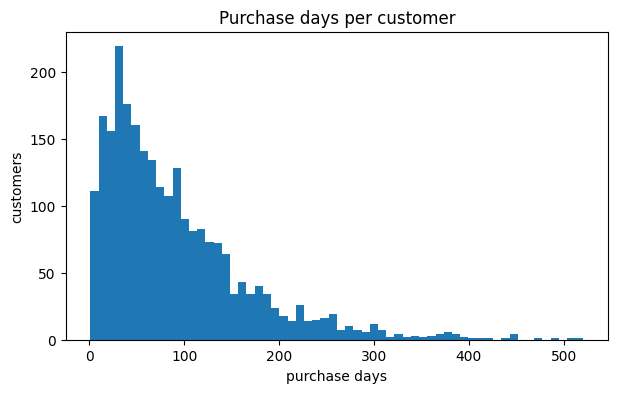

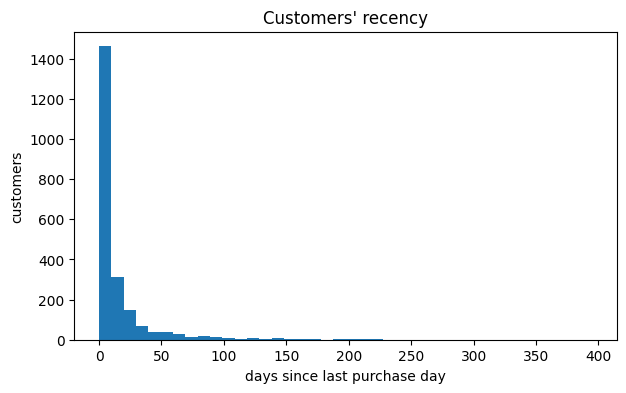

In [3]:
gap_sequences, customer_meta, purchase_days = build_customer_gap_sequences(
    tx_df=tx,
    cust_col=CUST_COL,
    date_col=DATE_COL,
    min_purchase_days=MIN_PURCHASE_DAYS,
    window_size=WINDOW_SIZE,
    forecast_horizon=max(FORECAST_HORIZON, DIRECT_OUTPUT_HORIZON),
)

print("Eligible customers:", len(gap_sequences))
display(customer_meta.head())

plt.figure(figsize=(7, 4))
plt.hist(purchase_days.values, bins=60)
plt.title('Purchase days per customer')
plt.xlabel('purchase days')
plt.ylabel('customers')
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(customer_meta['recency'], bins=40)
plt.title("Customers' recency")
plt.xlabel('days since last purchase day')
plt.ylabel('customers')
plt.show()

## 4) Split customers and assign behavioral clusters


Train customers: 1758 | Test customers: 440


,k,sse
0,2,6.226012e+06
1,3,4.274371e+06
2,4,3.275501e+06
3,5,2.592395e+06
4,6,2.160109e+06
5,7,1.771579e+06
6,8,1.560291e+06


,CustomerID,purchase_days,n_gaps,recency,frequency,avg_gap,std_gap,cv_gap,last_gap,cluster
0,900,521,520,0.0,521,1.248077,0.586709,0.470090,1.0,1
1,1510,504,503,0.0,504,1.250497,0.588892,0.470926,1.0,2
2,1795,494,493,1.0,494,1.259635,0.602171,0.478052,2.0,0
3,1228,469,468,0.0,469,1.497863,0.851090,0.568202,1.0,1
4,853,451,450,1.0,451,1.433333,1.137737,0.793769,3.0,0


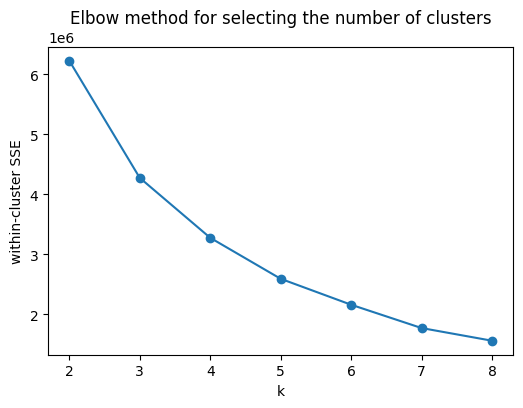

82

In [4]:
TRAIN_CUSTOMERS, TEST_CUSTOMERS = split_customers(
    customer_meta=customer_meta,
    cust_col=CUST_COL,
    test_frac=TEST_CUSTOMER_FRAC,
    seed=SEED,
)

train_meta_tmp = customer_meta.set_index(CUST_COL).loc[TRAIN_CUSTOMERS, FEATURE_COLS]
elbow_df = compute_elbow_curve(train_meta_tmp.values, k_values=range(2, 9), seed=SEED)

customer_meta, feature_scaler, kmeans = assign_customer_clusters(
    customer_meta=customer_meta,
    train_customers=TRAIN_CUSTOMERS,
    test_customers=TEST_CUSTOMERS,
    cust_col=CUST_COL,
    feature_cols=FEATURE_COLS,
    n_clusters=N_CLUSTERS,
    seed=SEED,
)

print("Train customers:", len(TRAIN_CUSTOMERS), "| Test customers:", len(TEST_CUSTOMERS))
display(elbow_df)
display(customer_meta.head())

plt.figure(figsize=(6, 4))
plt.plot(elbow_df['k'], elbow_df['sse'], marker='o')
plt.title('Elbow method for selecting the number of clusters')
plt.xlabel('k')
plt.ylabel('within-cluster SSE')
plt.show()

pd.Series(TRAIN_CUSTOMERS, name='train_customer').to_csv(ARTIFACT_ROOT / 'train_customers.csv', index=False)
pd.Series(TEST_CUSTOMERS, name='test_customer').to_csv(ARTIFACT_ROOT / 'test_customers.csv', index=False)
customer_meta.to_csv(ARTIFACT_ROOT / 'customer_meta_with_clusters.csv', index=False)
elbow_df.to_csv(ARTIFACT_ROOT / 'elbow_curve.csv', index=False)
(ARTIFACT_ROOT / 'feature_cols.json').write_text(json.dumps(FEATURE_COLS, indent=2), encoding='utf-8')


## 5) Helper functions for pooled direct multi-step Transformer training and holdout evaluation

In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def prepare_train_test_gap_split(series, horizon=FORECAST_HORIZON):
    arr = np.asarray(series, dtype=float).reshape(-1)
    if len(arr) <= int(horizon):
        raise ValueError("Series too short for the requested forecast horizon.")
    history = arr[:-int(horizon)]
    future = arr[-int(horizon):]
    return history, future

def make_multistep_windows(values, input_length=WINDOW_SIZE, output_horizon=DIRECT_OUTPUT_HORIZON):
    arr = np.asarray(values, dtype=float).reshape(-1)
    X, y = [], []
    for i in range(int(input_length), len(arr) - int(output_horizon) + 1):
        X.append(arr[i - int(input_length):i])
        y.append(arr[i:i + int(output_horizon)])
    if not X:
        return np.empty((0, int(input_length))), np.empty((0, int(output_horizon)))
    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)

def build_pooled_windows(customer_ids, gap_sequences, input_length=WINDOW_SIZE, output_horizon=DIRECT_OUTPUT_HORIZON):
    X_pool, y_pool = [], []
    for cust in list(customer_ids):
        history = np.asarray(gap_sequences[str(cust)], dtype=float).reshape(-1)
        X_local, y_local = make_multistep_windows(
            history,
            input_length=input_length,
            output_horizon=output_horizon,
        )
        if len(X_local):
            X_pool.append(X_local)
            y_pool.append(y_local)
    if not X_pool:
        return (
            np.empty((0, input_length)),
            np.empty((0, output_horizon)),
        )
    return np.concatenate(X_pool, axis=0), np.concatenate(y_pool, axis=0)

def evaluate_loaded_transformers(global_model, cluster_models, test_customers, gap_sequences, customer_meta):
    rows = []
    meta_lookup = customer_meta.set_index(CUST_COL)
    for cust in list(test_customers):
        history, future = prepare_train_test_gap_split(gap_sequences[str(cust)], horizon=FORECAST_HORIZON)
        pred_global = np.asarray(global_model.forecast_series(history, FORECAST_HORIZON), dtype=float).reshape(-1)

        rows.append({
            CUST_COL: str(cust),
            'model': 'Transformer',
            'history_len': int(len(history)),
            'mae': float(mean_absolute_error(future, pred_global)),
            'rmse': rmse(future, pred_global),
        })

        cluster_id = int(meta_lookup.loc[str(cust), 'cluster'])
        cluster_model = cluster_models.get(cluster_id)
        if cluster_model is not None:
            pred_cluster = np.asarray(cluster_model.forecast_series(history, FORECAST_HORIZON), dtype=float).reshape(-1)
            rows.append({
                CUST_COL: str(cust),
                'model': 'Transformer_Clustered',
                'history_len': int(len(history)),
                'mae': float(mean_absolute_error(future, pred_cluster)),
                'rmse': rmse(future, pred_cluster),
            })
    return pd.DataFrame(rows)

## 6) Train and save the global direct multi-step NPD Transformer

Training progress is shown directly in the notebook through Keras progress bars and per-epoch debug output.


In [6]:
X_global, y_global = build_pooled_windows(
    TRAIN_CUSTOMERS,
    gap_sequences,
    input_length=WINDOW_SIZE,
    output_horizon=DIRECT_OUTPUT_HORIZON,
)
if len(X_global) == 0:
    raise ValueError("No pooled NPD windows available for the global transformer training.")

print("Global transformer pooled windows:", X_global.shape, y_global.shape)

global_transformer = NPDTransformerForecaster(
    input_length=WINDOW_SIZE,
    output_horizon=DIRECT_OUTPUT_HORIZON,
    size_layer=TRANSFORMER_SIZE_LAYER,
    embedded_size=TRANSFORMER_EMBEDDED_SIZE,
    num_heads=TRANSFORMER_NUM_HEADS,
    dropout_rate=TRANSFORMER_DROPOUT,
    num_blocks=2,
    seed=SEED,
)

global_fit_info = global_transformer.fit(
    X_global,
    y_global,
    batch_size=TRANSFORMER_BATCH_SIZE,
    epochs=TRANSFORMER_EPOCHS,
    learning_rate=TRANSFORMER_LR,
    verbose=1,
    progress_label='NPD-global-direct',
    progress_report_every=1,
)
global_transformer.save(GLOBAL_MODEL_DIR)
(ARTIFACT_ROOT / 'global_fit_info.json').write_text(json.dumps(global_fit_info, indent=2), encoding='utf-8')
print("Saved global transformer to:", GLOBAL_MODEL_DIR)

Global transformer pooled windows: (149247, 12) (149247, 5)
[NPD-global-direct] start | epochs=50 | steps_per_epoch=4198
Epoch 1/50
4196/4198 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1863 - mae: 0.4182[NPD-global-direct] epoch 1: loss=0.1783 | mae=0.4037 | val_loss=0.1536 | val_mae=0.3701 | learning_rate=0.0010
4198/4198 ━━━━━━━━━━━━━━━━━━━━ 91s 21ms/step - loss: 0.1863 - mae: 0.4182 - val_loss: 0.1536 - val_mae: 0.3701 - learning_rate: 0.0010
Epoch 2/50
4196/4198 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1773 - mae: 0.4004[NPD-global-direct] epoch 2: loss=0.1762 | mae=0.3991 | val_loss=0.1539 | val_mae=0.3658 | learning_rate=0.0010
4198/4198 ━━━━━━━━━━━━━━━━━━━━ 80s 19ms/step - loss: 0.1773 - mae: 0.4004 - val_loss: 0.1539 - val_mae: 0.3658 - learning_rate: 0.0010
Epoch 3/50
4197/4198 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1770 - mae: 0.3996[NPD-global-direct] epoch 3: loss=0.1761 | mae=0.3987 | val_loss=0.1536 | val_mae=0.3683 | learning_rate=0.0010
4198/4198 ━━━━━━━━━━━━━━

## 7) Train and save clustered direct multi-step NPD Transformers

In [7]:
cluster_models = {}
cluster_fit_rows = []

for cluster_id, cluster_df in customer_meta[customer_meta[CUST_COL].isin(TRAIN_CUSTOMERS)].groupby('cluster'):
    cluster_customer_ids = cluster_df[CUST_COL].astype(str).tolist()
    X_cluster, y_cluster = build_pooled_windows(
        cluster_customer_ids,
        gap_sequences,
        input_length=WINDOW_SIZE,
        output_horizon=DIRECT_OUTPUT_HORIZON,
    )
    if len(X_cluster) == 0:
        print(f"Skipping cluster {cluster_id}: no pooled windows.")
        continue

    print(
        f"Training cluster {cluster_id} | customers={len(cluster_customer_ids)} "
        f"| windows={len(X_cluster)} | y_shape={y_cluster.shape}"
    )
    cluster_model = NPDTransformerForecaster(
        input_length=WINDOW_SIZE,
        output_horizon=DIRECT_OUTPUT_HORIZON,
        size_layer=TRANSFORMER_SIZE_LAYER,
        embedded_size=TRANSFORMER_EMBEDDED_SIZE,
        num_heads=TRANSFORMER_NUM_HEADS,
        dropout_rate=TRANSFORMER_DROPOUT,
        num_blocks=2,
        seed=SEED,
    )
    fit_info = cluster_model.fit(
        X_cluster,
        y_cluster,
        batch_size=TRANSFORMER_BATCH_SIZE,
        epochs=TRANSFORMER_EPOCHS,
        learning_rate=TRANSFORMER_LR,
        verbose=1,
        progress_label=f'NPD-cluster-{int(cluster_id)}-direct',
        progress_report_every=1,
    )
    cluster_dir = CLUSTER_MODEL_ROOT / f'cluster_{int(cluster_id)}'
    cluster_model.save(cluster_dir)
    cluster_models[int(cluster_id)] = cluster_model
    (cluster_dir / 'fit_info.json').write_text(json.dumps(fit_info, indent=2), encoding='utf-8')
    cluster_fit_rows.append({
        'cluster': int(cluster_id),
        'n_customers': int(len(cluster_customer_ids)),
        'n_windows': int(len(X_cluster)),
        'n_samples': int(fit_info['n_samples']),
    })

cluster_fit_df = pd.DataFrame(cluster_fit_rows).sort_values('cluster')
display(cluster_fit_df)
cluster_fit_df.to_csv(ARTIFACT_ROOT / 'cluster_training_summary.csv', index=False)
print("Saved clustered transformers to:", CLUSTER_MODEL_ROOT)

Training cluster 0 | customers=292 | windows=26388 | y_shape=(26388, 5)
[NPD-cluster-0-direct] start | epochs=50 | steps_per_epoch=743
Epoch 1/50
742/743 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1336 - mae: 0.3662[NPD-cluster-0-direct] epoch 1: loss=0.1134 | mae=0.3275 | val_loss=0.8251 | val_mae=1.1732 | learning_rate=0.0010
743/743 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 0.1336 - mae: 0.3661 - val_loss: 0.8251 - val_mae: 1.1732 - learning_rate: 0.0010
Epoch 2/50
742/743 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1040 - mae: 0.3070[NPD-cluster-0-direct] epoch 2: loss=0.1040 | mae=0.3063 | val_loss=0.8089 | val_mae=1.1604 | learning_rate=0.0010
743/743 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.1040 - mae: 0.3070 - val_loss: 0.8089 - val_mae: 1.1604 - learning_rate: 0.0010
Epoch 3/50
742/743 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1038 - mae: 0.3058[NPD-cluster-0-direct] epoch 3: loss=0.1039 | mae=0.3057 | val_loss=0.8199 | val_mae=1.1692 | learning_rate=0.0010
743/743 ━━━

,cluster,n_customers,n_windows,n_samples
0,0,292,26388,26388
1,1,869,73855,73855
2,2,536,44007,44007
3,3,61,4997,4997


Saved clustered transformers to: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/cluster_transformers


## 8) Holdout evaluation summary for downstream notebooks

This section only summarizes the saved Transformer artifacts. Benchmark baselines remain in the validation notebook.


In [8]:
holdout_results_df = evaluate_loaded_transformers(
    global_model=global_transformer,
    cluster_models=cluster_models,
    test_customers=TEST_CUSTOMERS,
    gap_sequences=gap_sequences,
    customer_meta=customer_meta,
)

holdout_summary_df = (
    holdout_results_df.groupby('model', as_index=False)
    .agg(
        avg_mae=('mae', 'mean'),
        avg_rmse=('rmse', 'mean'),
        avg_history_len=('history_len', 'mean'),
        n_customers=(CUST_COL, 'nunique'),
    )
    .sort_values('avg_rmse')
)

display(holdout_summary_df)
holdout_results_df.to_csv(ARTIFACT_ROOT / 'transformer_holdout_results.csv', index=False)
holdout_summary_df.to_csv(ARTIFACT_ROOT / 'transformer_holdout_summary.csv', index=False)

test_meta = customer_meta[customer_meta[CUST_COL].isin(TEST_CUSTOMERS)].copy().sort_values('frequency')
case_customers = {
    'low_frequency': str(test_meta.iloc[0][CUST_COL]) if len(test_meta) else None,
    'high_frequency': str(test_meta.iloc[-1][CUST_COL]) if len(test_meta) else None,
}
(ARTIFACT_ROOT / 'case_customers.json').write_text(json.dumps(case_customers, indent=2), encoding='utf-8')

summary_payload = {
    'config': {
        'forecast_horizon': FORECAST_HORIZON,
        'direct_output_horizon': DIRECT_OUTPUT_HORIZON,
        'min_purchase_days': MIN_PURCHASE_DAYS,
        'window_size': WINDOW_SIZE,
        'n_clusters': N_CLUSTERS,
        'test_customer_frac': TEST_CUSTOMER_FRAC,
        'transformer_epochs': TRANSFORMER_EPOCHS,
        'transformer_size_layer': TRANSFORMER_SIZE_LAYER,
        'transformer_embedded_size': TRANSFORMER_EMBEDDED_SIZE,
        'transformer_num_heads': TRANSFORMER_NUM_HEADS,
        'transformer_dropout': TRANSFORMER_DROPOUT,
        'transformer_batch_size': TRANSFORMER_BATCH_SIZE,
        'transformer_lr': TRANSFORMER_LR,
        'transformer_module_path': str(TRANSFORMER_MODULE_PATH),
        'seed': SEED,
    },
    'n_eligible_customers': int(len(gap_sequences)),
    'n_train_customers': int(len(TRAIN_CUSTOMERS)),
    'n_test_customers': int(len(TEST_CUSTOMERS)),
    'cluster_ids_trained': [int(x) for x in sorted(cluster_models.keys())],
    'case_customers': case_customers,
    'global_transformer': {},
    'clustered_transformer': {},
}

for _, row in holdout_summary_df.iterrows():
    payload = {
        'avg_mae': float(row['avg_mae']),
        'avg_rmse': float(row['avg_rmse']),
        'avg_history_len': float(row['avg_history_len']),
        'n_customers': int(row['n_customers']),
    }
    if row['model'] == 'Transformer':
        summary_payload['global_transformer'] = payload
    elif row['model'] == 'Transformer_Clustered':
        summary_payload['clustered_transformer'] = payload

(ARTIFACT_ROOT / 'training_summary.json').write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')
display(summary_payload)
print("Saved summary to:", ARTIFACT_ROOT / 'training_summary.json')

,model,avg_mae,avg_rmse,avg_history_len,n_customers
0,Transformer,8.291535,11.545185,90.990909,440
1,Transformer_Clustered,8.465551,11.888449,90.990909,440


{'config': {'forecast_horizon': 5,
  'direct_output_horizon': 5,
  'min_purchase_days': 20,
  'window_size': 12,
  'n_clusters': 4,
  'test_customer_frac': 0.2,
  'transformer_epochs': 50,
  'transformer_size_layer': 128,
  'transformer_embedded_size': 128,
  'transformer_num_heads': 8,
  'transformer_dropout': 0.1,
  'transformer_batch_size': 32,
  'transformer_lr': 0.001,
  'transformer_module_path': '/Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/src/transformer_forecaster.py',
  'seed': 42},
 'n_eligible_customers': 2198,
 'n_train_customers': 1758,
 'n_test_customers': 440,
 'cluster_ids_trained': [0, 1, 2, 3],
 'case_customers': {'low_frequency': '610', 'high_frequency': '1510'},
 'global_transformer': {'avg_mae': 8.29153483506718,
  'avg_rmse': 11.545185384784823,
  'avg_history_len': 90.99090909090908,
  'n_customers': 440},
 'clustered_transformer': {'avg_mae': 8.465551422199356,
  'avg_rmse': 11.888448541714904,
  'avg_history_len'

Saved summary to: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/npd_transformer_bundle/training_summary.json
